In [1]:
import os
os.environ["CBEAM_BACKEND"] = "numpy"
os.environ["CBEAM_JAX_DEVICE_INDEX"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from multi_wvl_pipeline import *

"""
End-to-end example: propagate a batch of aberration configurations at
several native wavelengths, interpolate onto a fine grid, and hand the
result to the spectral extraction module.
"""

import specula
specula.init(0)
from specula.data_objects.ifunc import IFunc
from batch_propagation_pipeline import get_simulation_parameters, create_random_aberration_configs
from spectral_extraction_module import SpectralImageSimulator, SpectralExtractor


import time
import numpy as np
 
from multi_wvl_pipeline import build_and_characterize_lantern_at_wavelength
from batch_propagation_pipeline import BatchPropagationPipeline
 

wvl_samples = 17
piston_samples = 21

# wvl_samples = 33
# piston_samples = 81


def profile_multiwavelength_preset(
    base_params, ifunc, native_wavelengths_nm,
    field_gen_on_gpu=False, field_gen_chunk_size=64,
):
    native_wavelengths_nm = np.asarray(sorted(native_wavelengths_nm), dtype=np.float64)
 
    char_times = []
    pipeline_times = []
    pupil_template = None
    shared_PL_N = build_lantern_geometry(base_params)
 
    for wl in native_wavelengths_nm:
        t0 = time.perf_counter()
        p_lambda, prop12 = build_and_characterize_lantern_at_wavelength(
            base_params, wl, PL_N=shared_PL_N, verbose=False)
        t1 = time.perf_counter()
 
        try:
            pipeline = BatchPropagationPipeline(
                prop12, p_lambda, ifunc,
                field_gen_on_gpu=field_gen_on_gpu,
                field_gen_chunk_size=field_gen_chunk_size,
                field_gen_pupil_template=pupil_template,
            )
        except TypeError:
            pipeline = BatchPropagationPipeline(
                prop12, p_lambda, ifunc,
                field_gen_on_gpu=field_gen_on_gpu,
                field_gen_chunk_size=field_gen_chunk_size,
            )
        t2 = time.perf_counter()
 
        if pupil_template is None:
            fg = pipeline._field_gen_np
            pupil_template = (fg.mask_np, fg.grid_size, fg.num_modes, fg.ifunc_matrix)
 
        char_times.append(t1 - t0)
        pipeline_times.append(t2 - t1)
        print(f"{wl:8.2f} nm   characterize/load: {t1-t0:7.3f} s   "
              f"pipeline build: {t2-t1:7.3f} s")
 
    char_times = np.array(char_times)
    pipeline_times = np.array(pipeline_times)
 
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"build_and_characterize_lantern_at_wavelength: "
          f"total {char_times.sum():7.2f} s   "
          f"mean {char_times.mean():6.3f} s   "
          f"min {char_times.min():6.3f} s   max {char_times.max():6.3f} s")
    print(f"BatchPropagationPipeline construction:         "
          f"total {pipeline_times.sum():7.2f} s   "
          f"mean {pipeline_times.mean():6.3f} s   "
          f"min {pipeline_times.min():6.3f} s   max {pipeline_times.max():6.3f} s")
    print(f"\nGrand total: {char_times.sum() + pipeline_times.sum():7.2f} s "
          f"over {len(native_wavelengths_nm)} wavelengths")
    print("=" * 60)
 
    return char_times, pipeline_times

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


2026-08-18 12:14:43,971 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.1.1
2026-08-18 12:14:44,323 [INFO]: [specula]: Default device is GPU number 0


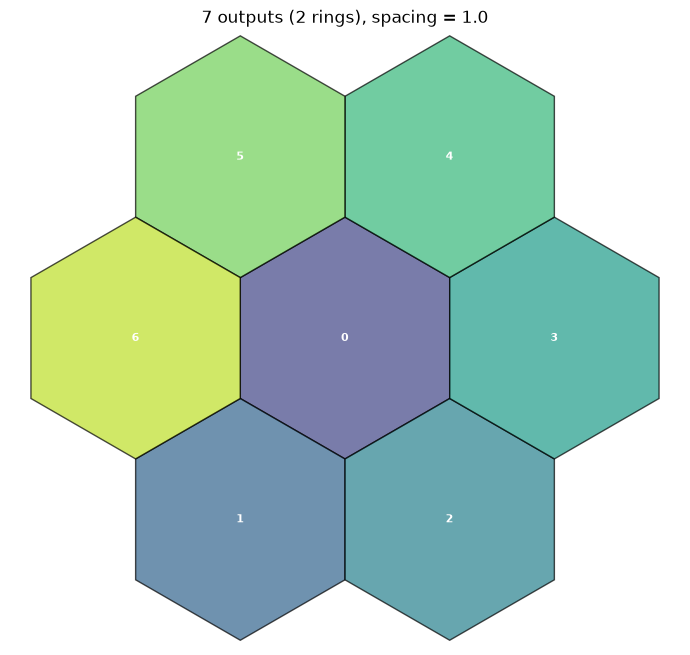

Number of positions: 7


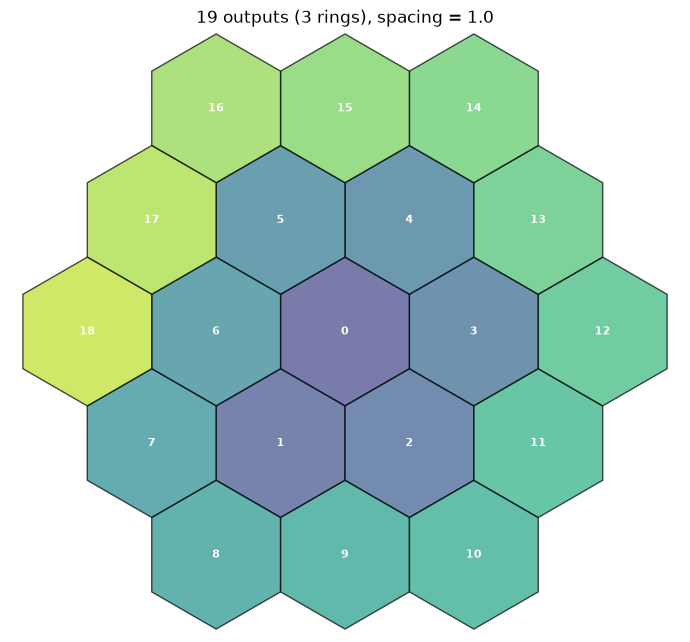

Number of positions: 19


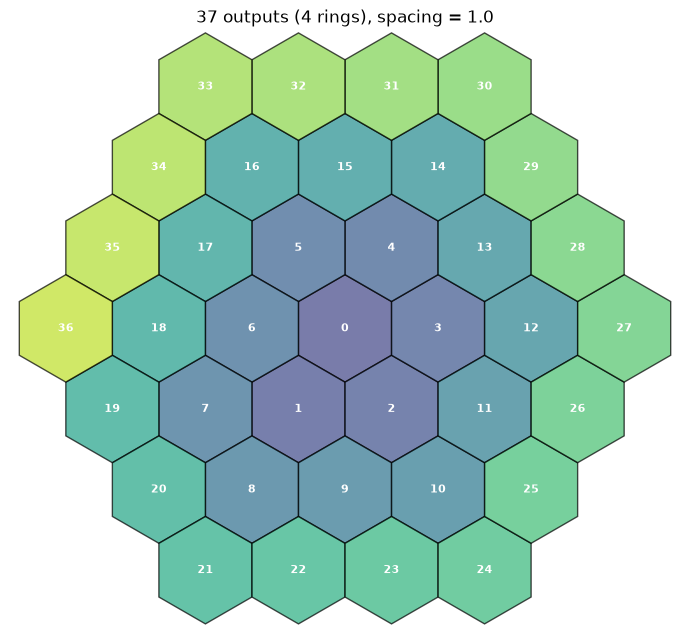

Number of positions: 37


In [2]:
from cbeam.waveguide import hex_ring_positions
coords = hex_ring_positions(2, plot=True)
print(f"Number of positions: {len(coords)}")
coords = hex_ring_positions(3, plot=True)
print(f"Number of positions: {len(coords)}")
coords = hex_ring_positions(4, plot=True)
print(f"Number of positions: {len(coords)}")

In [3]:
from multi_wvl_pipeline import *
"""
End-to-end example: propagate a batch of aberration configurations at
several native wavelengths, interpolate onto a fine grid, and hand the
result to the spectral extraction module.
"""
import specula
specula.init(0)
from specula.data_objects.ifunc import IFunc
from batch_propagation_pipeline import get_simulation_parameters, create_random_aberration_configs, create_ramp_aberration_configs
from spectral_extraction_module import SpectralImageSimulator, SpectralExtractor

print("=" * 60)
print("MULTI-WAVELENGTH PHOTONIC LANTERN PROPAGATION")
print("=" * 60)


2026-08-18 12:14:44,844 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.1.1
2026-08-18 12:14:44,846 [INFO]: [specula]: Default device is GPU number 0


MULTI-WAVELENGTH PHOTONIC LANTERN PROPAGATION


In [4]:

# NOTE THIS! N_RINGS determines the number of output signals
base_params = get_simulation_parameters(nrings=3)
ifunc = IFunc.restore(base_params["ifunc_file"])

# Coarse native solve grid: physically propagate at these wavelengths.
native_wl_nm = np.linspace(640, 960, wvl_samples)

mwp = MultiWavelengthPropagationPipeline(
    base_params=base_params,
    ifunc=ifunc,
    native_wavelengths_nm=native_wl_nm,
    field_gen_on_gpu=False,
    field_gen_chunk_size=64,
)

n_total_modes = mwp.num_modes
coeff_matrix, labels = create_ramp_aberration_configs([0], piston_samples, -2000, 2000)

output_wl_nm = np.linspace(640, 960, wvl_samples)
power_spectra, wl_out = mwp.get_power_spectra(
    coeff_matrix,
    output_wavelengths_nm=output_wl_nm,
    use_gpu=False,
    prop_chunk_size=32,
)
print(f"\npower_spectra shape: {power_spectra.shape}  "
      f"(n_wavelengths={power_spectra.shape[0]}, "
      f"n_fields={power_spectra.shape[1]}, n_fibers={power_spectra.shape[2]})")


#  --- DIAGNOSTIC: run this once to see where preset-phase time goes ---
# char_times, pipeline_times = profile_multiwavelength_preset(
#     base_params, ifunc, native_wl_nm,
#     field_gen_on_gpu=False, field_gen_chunk_size=64,
# )
#  -----------------------------------------------------------------------


[MultiWavelength] Configured for 17 native wavelengths (640.0-960.0 nm). Engines are built and released one wavelength at a time during propagate_batch() (cache_engines=False).
[MultiWavelength] Propagating at 640.00 nm (1/17) ...
    [19port_0640_front] loaded cached characterization.
    [19port_0640_back] loaded cached characterization.
[Interpolation Setup]
  Padded grid size: 1600
  Grid parity: even
  Center offset: 800.0
  Pixel scale: 0.8 μm/pixel
  Mesh X range: [-26.852, 26.852] μm
  Mesh Y range: [-27.000, 27.000] μm
  Valid interpolation points: 12495 / 12495
  Propagating 21 fields (chunk_size=32) ...
    propagation chunk 0–20 done.
  Batch propagation complete.
[MultiWavelength] Propagating at 660.00 nm (2/17) ...
    [19port_0660_front] loaded cached characterization.
    [19port_0660_back] loaded cached characterization.
[Interpolation Setup]
  Padded grid size: 1600
  Grid parity: even
  Center offset: 800.0
  Pixel scale: 0.825 μm/pixel
  Mesh X range: [-26.852, 26.8

In [5]:
spectral_cfg = build_spectral_config_from_wavelength_grid(wl_out)

In [6]:
import numpy as np
import pickle

# --- After running the simulation ---
# Save with np.savez (or np.savez_compressed for large data)
np.savez('lantern19_results' + str(wvl_samples) + '.npz',
         power_spectra=power_spectra,
         wavelengths=wl_out,
         coeff_matrix=coeff_matrix,
         labels=labels)

# If you also need the spectral config for the extractor, you can save it
# with pickle (or rebuild it later from wl_out)
with open('spectral_cfg.pkl', 'wb') as f:
    pickle.dump(spectral_cfg, f)

# Also save fiber_positions if you need them for detector-stage plotting
# (they come from the lantern geometry, but you can recompute them from nrings)
# Or save them as well:
# np.savez('lantern_results.npz', ..., fiber_positions=fiber_positions)

print("Simulation results saved.")

Simulation results saved.


In [7]:
import numpy as np
import pickle
from multi_wavelength_vis import *   # your plotting functions
from spectral_extraction_module import SpectralImageSimulator, SpectralExtractor
from multi_wvl_pipeline import build_spectral_config_from_wavelength_grid

with open('spectral_cfg.pkl', 'rb') as f:
    spectral_cfg = pickle.load(f)
# Load arrays
data = np.load('lantern19_results' + str(wvl_samples) + '.npz')
power_spectra = data['power_spectra']
wl_out = data['wavelengths']
coeff_matrix = data['coeff_matrix'] if 'coeff_matrix' in data else None
labels = data['labels'] if 'labels' in data else None

In [8]:
simulator = SpectralImageSimulator(spectral_cfg)

SpectralImageSimulator initialized:
  Wavelength range: 640.0–960.0 nm
  Spectral bins: 17
  Dispersion: 3.333 pix/nm
  Detector: 2048 × 512 pixels


In [15]:
field_idx = 0 # int(piston_samples / 2)

In [16]:
extractor = SpectralExtractor(spectral_cfg)

In [17]:
spectra_field0 = spectra_for_field(power_spectra, field_idx=field_idx)

In [18]:
image, fiber_positions = simulator.create_spectral_image(
    modal_powers=None, spectra=spectra_field0, add_noise=False, exposure_time=1.0,
)

In [19]:
extracted, variance = extractor.extract_spectra(image, fiber_positions, method='aperture')
print(f"Extracted spectra shape: {extracted.shape}")

Extracted spectra shape: (17, 19)


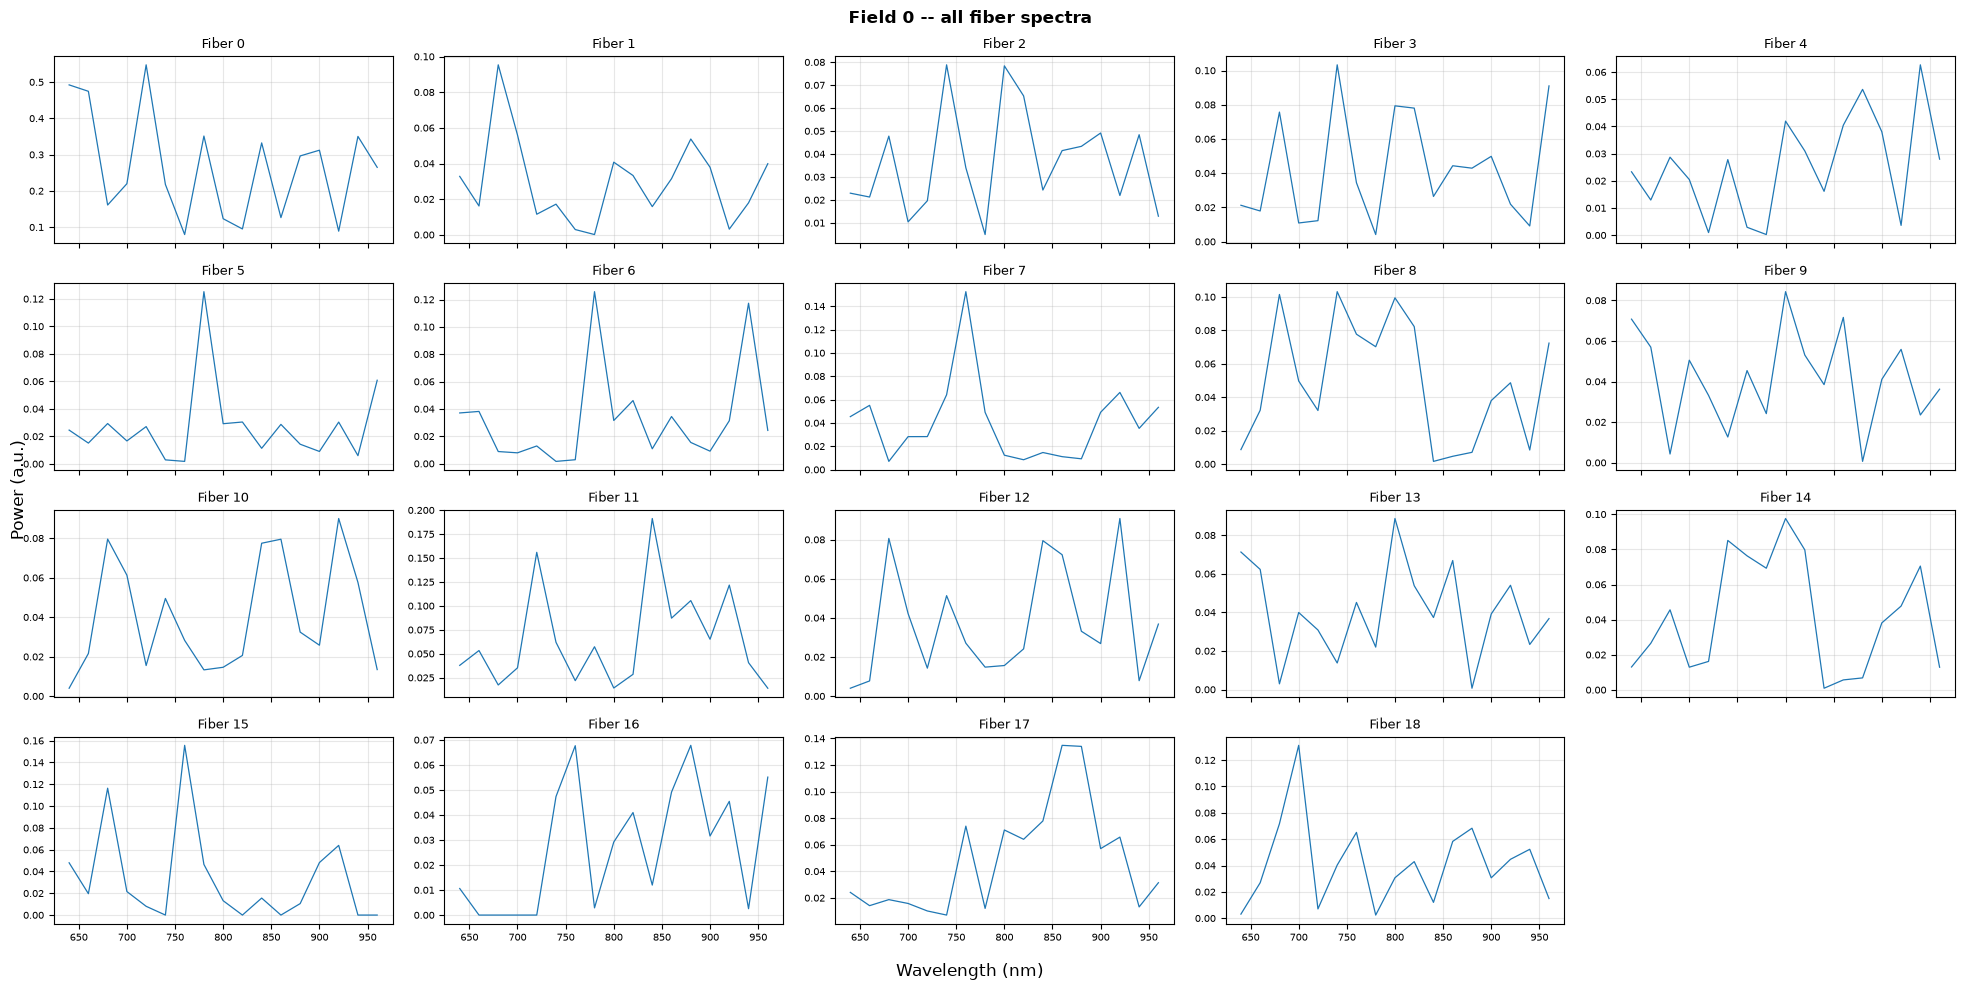

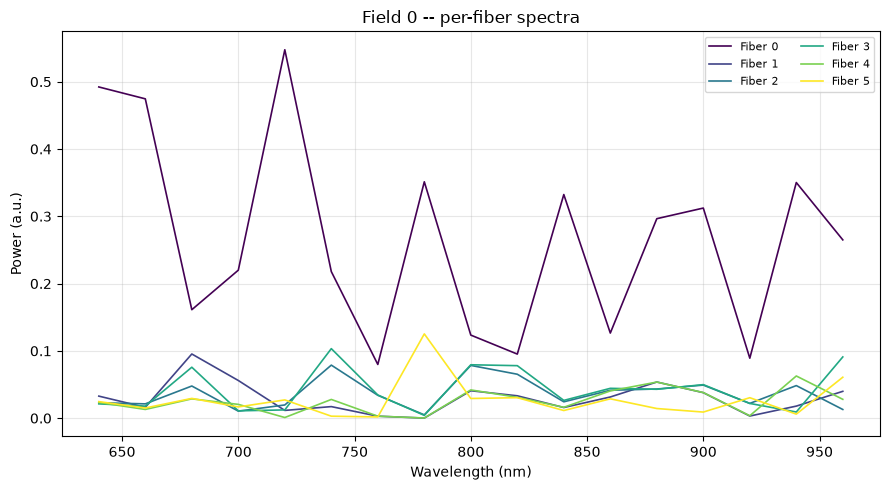

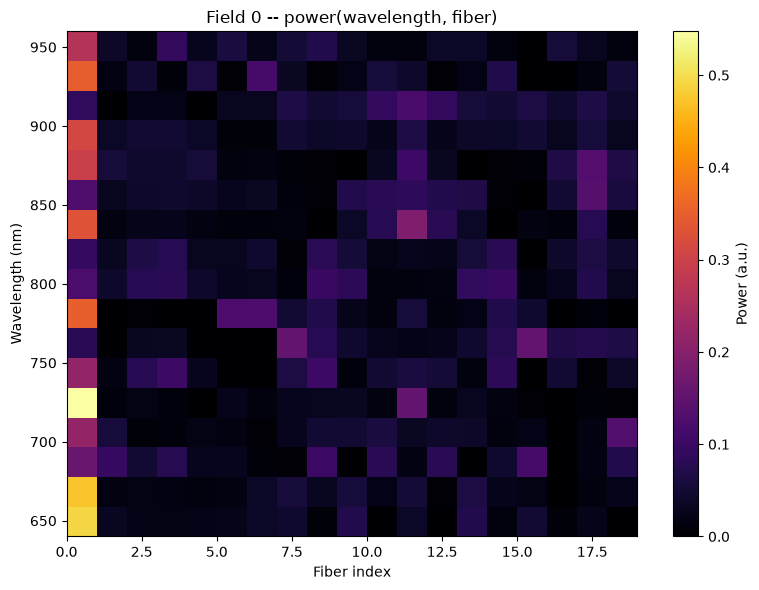

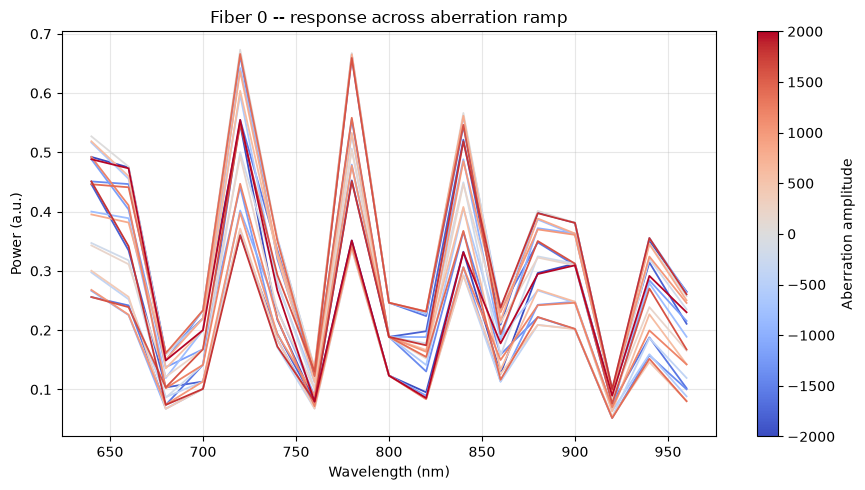

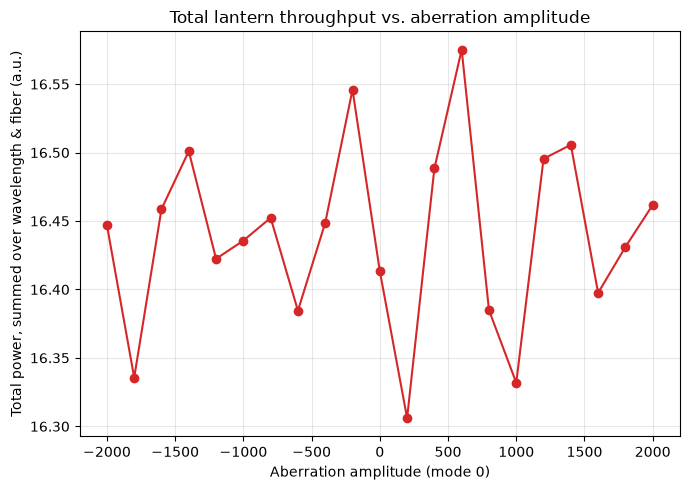

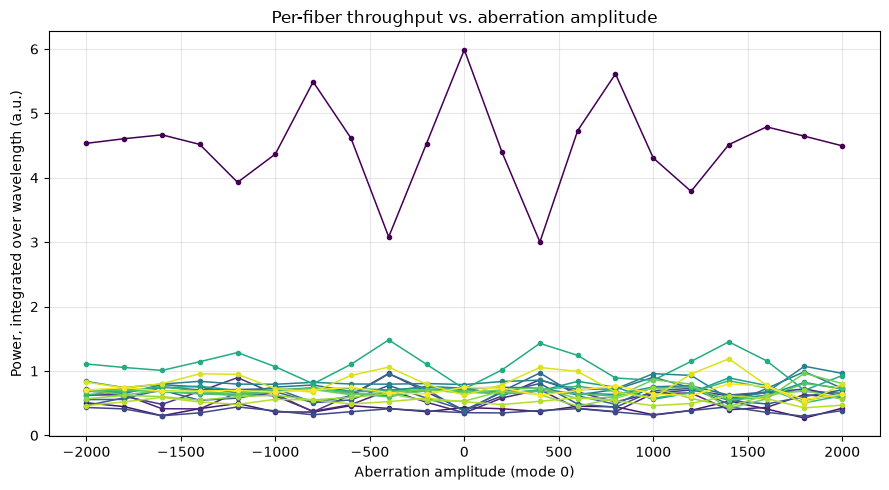

SpectralImageSimulator initialized:
  Wavelength range: 640.0–960.0 nm
  Spectral bins: 17
  Dispersion: 3.333 pix/nm
  Detector: 2048 × 512 pixels


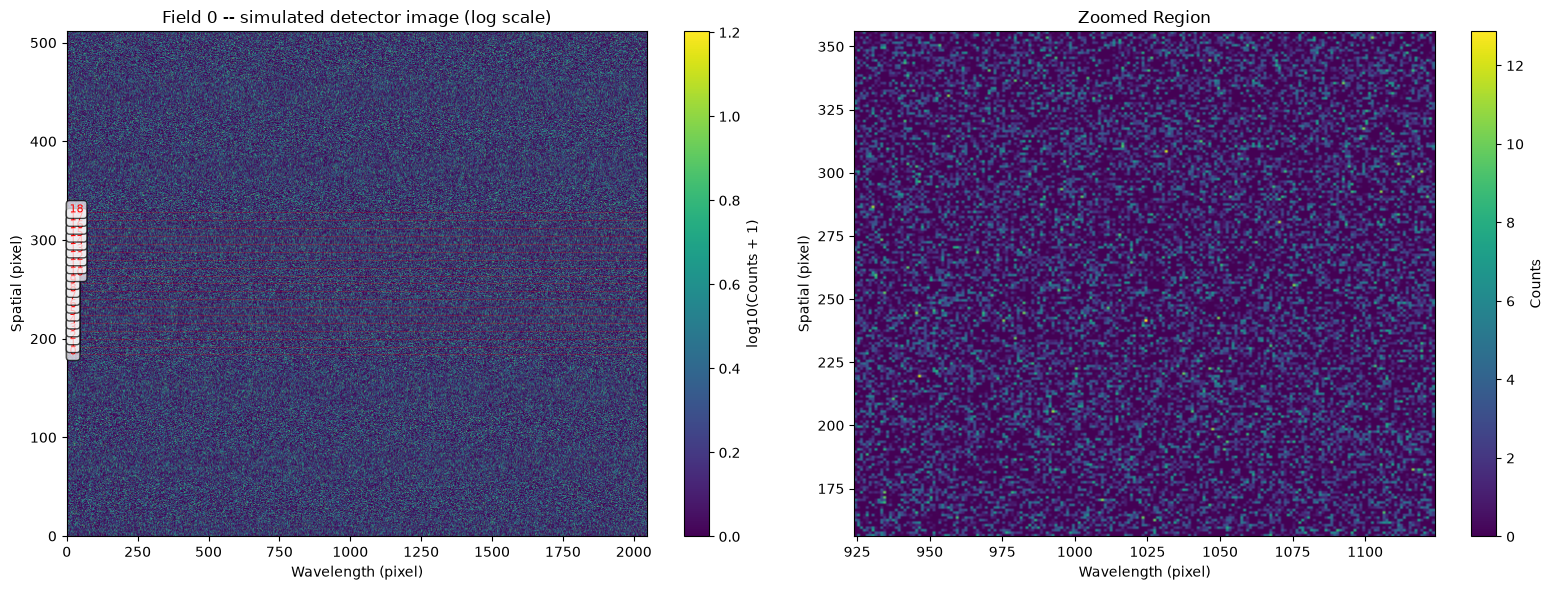

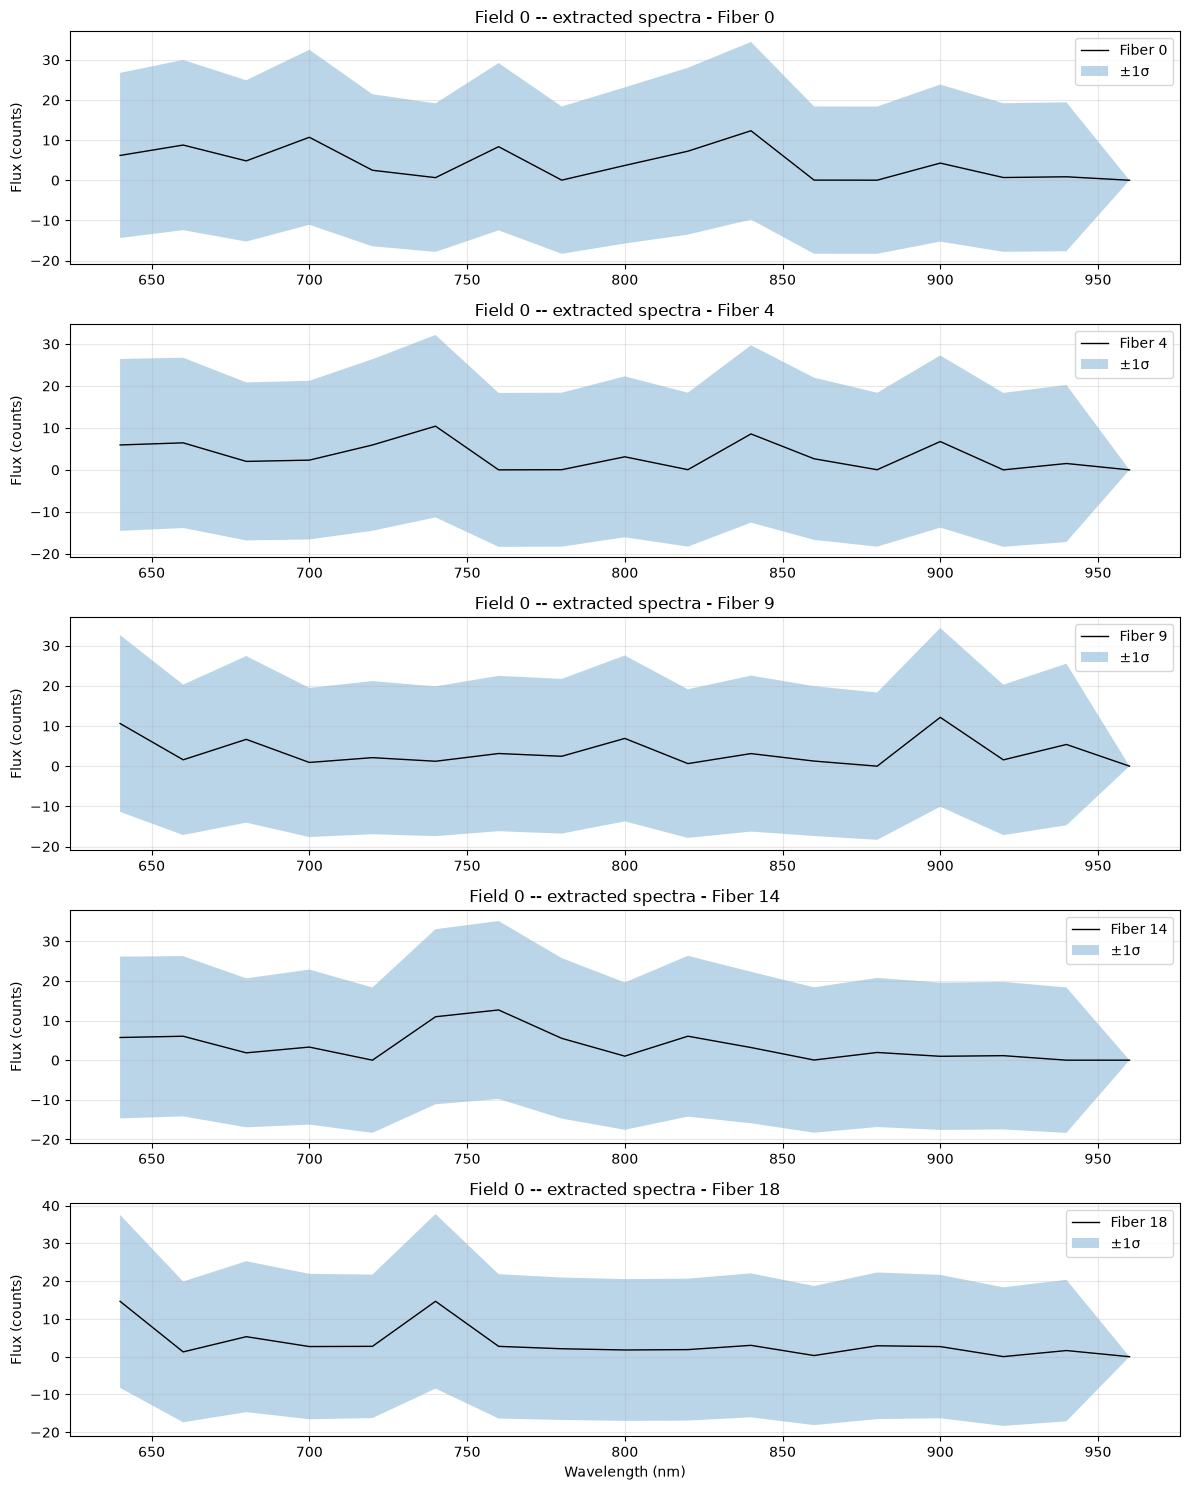

In [20]:
from multi_wavelength_vis import *

# All spectra for one field, one per subplot
plot_spectra_grid(power_spectra, wl_out, field_idx=field_idx)
# A few fibers overlaid on one axes
plot_fiber_spectra(power_spectra, wl_out, field_idx=field_idx, fiber_indices=[0, 1, 2, 3, 4, 5])
# Wavelength x fiber heatmap for one field
plot_wavelength_fiber_heatmap(power_spectra, wl_out, field_idx=field_idx)
amplitudes = coeff_matrix[:, 0]  # the ramped mode's amplitude per field
plot_ramp_response(power_spectra, wl_out, amplitudes, fiber_idx=0, labels=labels)
plot_total_throughput_vs_amplitude(power_spectra, amplitudes, labels=labels, mode_label="mode 0")
plot_per_fiber_throughput_vs_amplitude(power_spectra, amplitudes, mode_label="mode 0")
# Detector-plane stage (image + extracted spectra) for one field, in one call
image, extracted, variance = plot_detector_stage_for_field(power_spectra, wl_out, field_idx=0)